# Project 1 — Regression, resampling methods and gradient descent

**FYS-STK3155/4155**, University of Oslo, autumn 2026
**Parisa Amin**

We study polynomial regression on Runge's function

$$f(x) = \frac{1}{1+25x^2}, \qquad x \in [-1, 1],$$

with ordinary least squares, Ridge and Lasso; the bootstrap and $k$-fold
cross-validation; and gradient-descent optimisers.

Reusable functions live in `regression.py`; this notebook runs the experiments.

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# pick up edits to regression.py without restarting the kernel
%load_ext autoreload
%autoreload 2

from regression import (runge, make_data, polynomial_features, MSE, R2, ols, fit_predict,
                        BLUE, RED, YELLOW, GREY, GREEN)

np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
# Part a) Ordinary Least Squares

**Goal:** build the machinery, and see overfitting happen — training MSE falling
for ever while test MSE turns back up, driven by coefficients that explode.

## a.1 The data

Generate Runge data on $[-1,1]$ with noise $\varepsilon\sim\mathcal{N}(0,\sigma^2)$,
$\sigma = 0.1$. Plot the noisy samples against the true function to check it looks right.

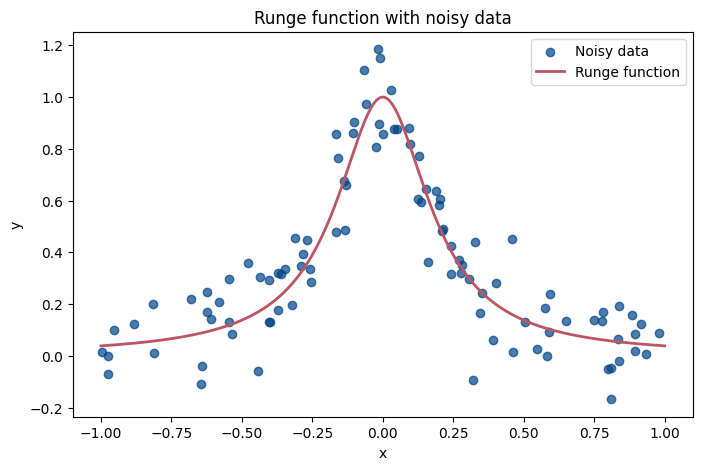

In [34]:
x , y= make_data(n= 100 , sigma= 0.1 , seed= 2026)
x_fine = np.linspace(-1,1, 1000)
y_fine = runge(x_fine)


plt.figure(figsize=(8,5))
plt.scatter(x,y, label= "Noisy data" , color= BLUE , alpha= 0.7)
plt.plot(x_fine , y_fine , label= "Runge function" , color= RED , linewidth= 2)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Runge function with noisy data")
plt.legend()

plt.show()


## a.2 Train/test split and scaling

Split roughly 80/20. Then **centre `y` and standardise the feature columns —
fitting the scaler on the training data only**, and applying those same numbers to
the test data.

Why it matters: if the scaler sees the test set, information has leaked from test
into train and your error estimate is optimistically biased. The project asks for a
critical discussion of this, so write down what you did and why.

In [35]:
from sklearn.model_selection import train_test_split

x_train , x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2 , random_state= 2026)

print(len(x_test))
print(len(x_train))


20
80


## a.3 MSE and $R^2$ against polynomial degree

For degree $= 1 \ldots 15$: build the design matrix, fit OLS, record training and
test MSE and $R^2$.

Expect: training MSE falls monotonically; test MSE falls then rises. Use a log
scale on the MSE axis and mark the noise floor $\sigma^2$ with a grey dashed line —
no model can do better than that.

In [36]:
print(x_train.shape)
print(x_train.ndim)

(80,)
1


In [37]:

# x = raw input vector, X = polynomial design matrix
degrees = np.arange(1, 16)

#print(degrees)

mse_train= np.zeros(len(degrees))
mse_test= np.zeros(len(degrees))

r2_train= np.zeros(len(degrees))
r2_test= np.zeros(len(degrees))

for i, degree in enumerate(degrees):

    X_train= polynomial_features(x_train, degree)
    X_test= polynomial_features(x_test, degree)

    X_mean= np.mean(X_train, axis=0)  #capital X
    X_std= np.std(X_train, axis=0)    #capital X

    X_train_scaled= (X_train - X_mean)/X_std
    X_test_scaled= (X_test - X_mean)/ X_std

    y_mean= np.mean(y_train)
    y_train_centered= y_train - y_mean

    theta= ols(X_train_scaled, y_train_centered)

    y_train_pred = X_train_scaled @ theta + y_mean
    y_test_pred = X_test_scaled @ theta + y_mean


    mse_train[i]= MSE(y_train, y_train_pred)
    mse_test[i]= MSE(y_test, y_test_pred)

    r2_train[i]= R2(y_train, y_train_pred)
    r2_test[i]= R2(y_test, y_test_pred) 

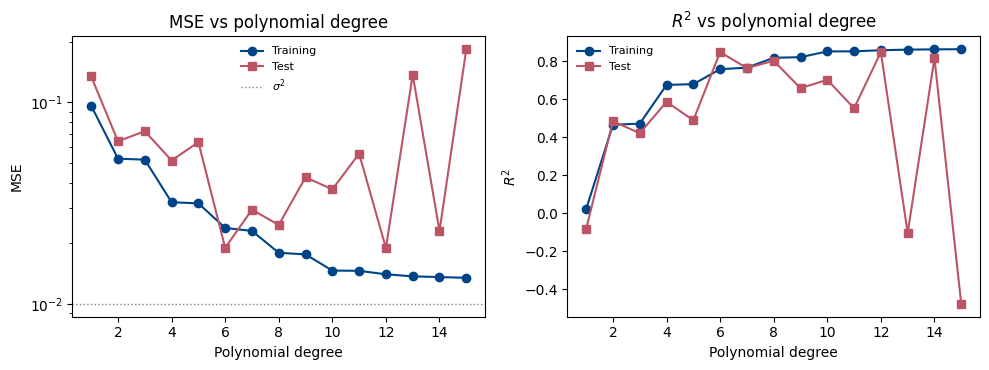

In [38]:
plt.figure(figsize=(10, 3.8))

#MSE plot
plt.subplot(1, 2, 1)

plt.plot(degrees, mse_train,"o-", color=BLUE, label="Training")
plt.plot(degrees, mse_test, "s-",color=RED, label="Test")

plt.yscale("log")                                      # MSE panel only
plt.axhline(0.1**2, color="gray", ls=":", lw=1, label=r"$\sigma^2$")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.title("MSE vs polynomial degree")
plt.legend(frameon=False, fontsize=8)

#R2 plot
plt.subplot(1, 2, 2)

plt.plot(degrees, r2_train,"o-", color=BLUE, label="Training")
plt.plot(degrees, r2_test,"s-", color=RED, label="Test")

plt.xlabel("Polynomial degree")
plt.ylabel( r"$R^2$ " )
plt.title( r"$R^2$ vs polynomial degree")
plt.legend(frameon=False, fontsize=8)


plt.tight_layout()
plt.savefig("../results/a3_mse_r2.pdf", bbox_inches="tight")
plt.show()


## a.4 The coefficients $\theta$ against degree

This is the figure that explains the U-shape. Plot the magnitude of the fitted
coefficients as the degree grows — expect them to reach enormous values with
alternating signs, because the design matrix becomes nearly singular and the fit
relies on huge cancelling terms.

A log scale on $|\theta_j|$ makes it readable.

In [39]:
 # a.4 — how the coefficients grow with degree

theta_all = []
max_theta = np.zeros(len(degrees))

for i, degree in enumerate(degrees):

    X_train= polynomial_features(x_train, degree)

    X_mean= np.mean(X_train, axis=0)
    X_std = np.std(X_train, axis=0)

    X_train_scaled= (X_train - X_mean) / X_std

    y_mean= np.mean(y_train)
    y_train_centered= y_train - y_mean

    theta = ols(X_train_scaled, y_train_centered)
    theta_all.append(theta)

    max_theta[i] = np.max(np.abs(theta))



In [40]:
#print(max_theta)
print(theta_all[5])

print(max_theta[5])

[-0.0534 -1.3045  0.0159  2.1179  0.0137 -1.0449]
2.117857348560849


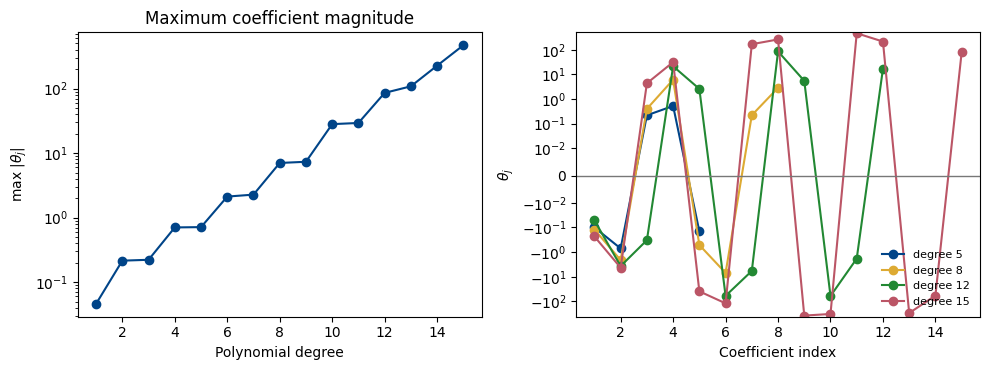

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))


##Left panel

axes[0].semilogy(degrees, max_theta, "o-", color=BLUE )

axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel(r"max $|\theta_j|$")
axes[0].set_title("Maximum coefficient magnitude")


## Right panel
for degree, c in zip([5, 8, 12, 15], [BLUE, YELLOW, GREEN, RED]):
    theta = theta_all[degree - 1]
    j = np.arange(1, degree + 1)
    axes[1].plot(j, theta, "o-", color=c, label=f"degree {degree}")



axes[1].axhline(0, color=GREY, linewidth=1)
axes[1].set_yscale("symlog", linthresh=1e-2)
axes[1].set_xlabel("Coefficient index")
axes[1].set_ylabel(r"$\theta_j$")
axes[1].legend(frameon= False, fontsize=8)

plt.tight_layout()
plt.savefig("../results/a4_theta.pdf", bbox_inches="tight")
plt.show()




## a.5 Dependence on the number of points and the noise level

Repeat the degree sweep for a few values of $n$ and of $\sigma$.

Expect: more data supports a higher degree before overfitting sets in; more noise
pushes the optimal degree down.

In [42]:
# Different number of points
degrees = np.arange(1, 16)
n_values = [50, 100, 200, 1000]
sigma_fixed= 0.1

mse_by_n= {}


for n in n_values:

    #Generate new data set
    x_n , y_n = make_data(n=n, sigma=sigma_fixed, seed=2026)

    #split and test
    x_train_n, x_test_n, y_train_n , y_test_n = train_test_split(x_n, y_n, test_size= 0.2, random_state=2026)

     # One MSE value for each degree
    mse_test_n = np.zeros(len(degrees))

    for i , degree in enumerate(degrees):
        y_train_pred , y_test_pred , theta = fit_predict(x_train_n, x_test_n, y_train_n, degree)

        mse_test_n[i] = MSE(y_test_n, y_test_pred)


    mse_by_n[n] = mse_test_n



In [43]:
sigma_values = [0.01, 0.1, 0.3]
n_fixed = 100

mse_by_sigma = {}

for sigma in sigma_values:
    #Generate new data set
    x_s , y_s = make_data(n=n_fixed, sigma=sigma, seed=2026)

    #split and test
    x_train_s, x_test_s, y_train_s , y_test_s = train_test_split(x_s, y_s, test_size= 0.2, random_state=2026)


    # Store test MSE for all degrees
    mse_test_s = np.zeros(len(degrees))

    for i , degree in enumerate(degrees):
        y_train_pred , y_test_pred , theta = fit_predict(x_train_s, x_test_s, y_train_s, degree)

        mse_test_s[i] = MSE(y_test_s, y_test_pred)


    mse_by_sigma[sigma] = mse_test_s

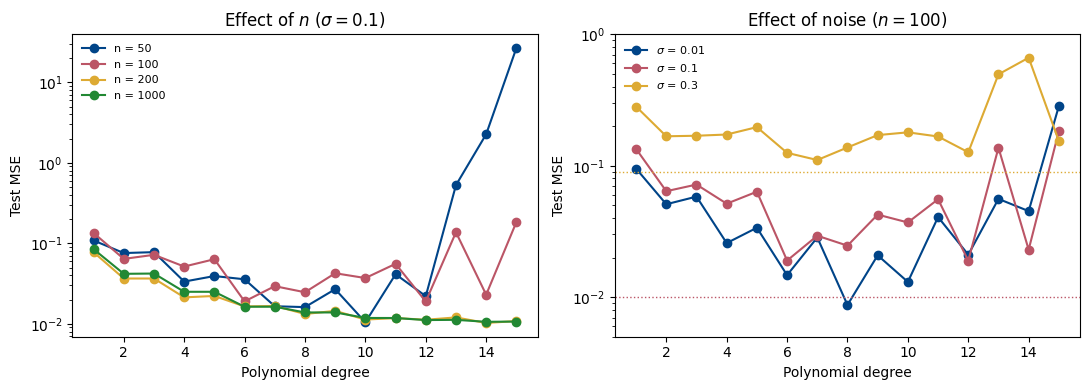

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors = [BLUE, RED, YELLOW, GREEN]

  
# --------------------------------------------------
# Left panel: different n
# --------------------------------------------------

for i, n in enumerate(n_values):

      axes[0].semilogy(degrees, mse_by_n[n], "o-", color=colors[i], label=f"n = {n}")

axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("Test MSE")
axes[0].set_title(r"Effect of $n$ ($\sigma=0.1$)")
axes[0].legend(frameon=False, fontsize=8)


# --------------------------------------------------
# Right panel: different sigma
# --------------------------------------------------

for i, sigma in enumerate(sigma_values):

    axes[1].semilogy(degrees, mse_by_sigma[sigma], "o-", color=colors[i], label=fr"$\sigma$ = {sigma}")
  
    axes[1].axhline(sigma**2, color=colors[i], linestyle=":", linewidth=1)
  
axes[1].set_ylim(5e-3, 1)
axes[1].set_xlabel("Polynomial degree")
axes[1].set_ylabel("Test MSE")
axes[1].set_title(r"Effect of noise ($n=100$)")
axes[1].legend(frameon=False, fontsize=8)

 
plt.tight_layout()
plt.savefig("../results/a5_n_sigma.pdf", bbox_inches="tight")
plt.show()
  


---
# Part b) Ridge regression

**Goal:** control the explosion. Ridge minimises

$$C(\theta) = \frac{1}{n}\lVert X\theta - y \rVert^2 + \lambda\lVert\theta\rVert^2,
\qquad
\theta = (X^TX + n\lambda I)^{-1}X^Ty.$$

**The factor $n$ comes from the $1/n$ in the cost function — don't drop it.**

## b.1 Implement Ridge, and benchmark it

Add `ridge(X, y, lam)` to `regression.py`, then check it two ways:

1. `lam = 0` must reproduce your OLS result exactly
2. it must match `Ridge(alpha=n*lam, fit_intercept=False)` from scikit-learn

These benchmarks belong in the report — the course guidelines call validation
against known results *"extremely important"*.

In [45]:
import regression
import importlib
importlib.reload(regression)

from regression import ridge

In [46]:
from sklearn.linear_model import Ridge

In [47]:
theta_ols = ols(X_train_scaled, y_train_centered)
theta_ridge0= ridge(X_train_scaled, y_train_centered, 0)

print("max |OLS - Ridge(lambda=0)| =", np.max(np.abs(theta_ols - theta_ridge0 )))

print(np.allclose(theta_ols, theta_ridge0))


max |OLS - Ridge(lambda=0)| = 0.0003622671614493811
True


## b.1b Our Ridge vs scikit-learn Ridge

In [48]:
theta_ours = ridge( X_train_scaled, y_train_centered, lam = 0.01)

In [49]:
n= X_train_scaled.shape[0]

lam= 0.01
model_Ridge= Ridge(alpha= n*lam , fit_intercept= False)
model_Ridge.fit(X_train_scaled, y_train_centered)
theta_sklearn = model_Ridge.coef_

print("max |sklearnRidge - OurRidge| =", np.max(np.abs(theta_sklearn - theta_ours )))
print(np.allclose(theta_sklearn, theta_ours))

max |sklearnRidge - OurRidge| = 4.066191827689636e-15
True


## b.2 MSE against $\lambda$, at fixed degree

In [50]:
lambdas =np.logspace(-8, 2, 9)
print(lambdas)

[  0.       0.       0.       0.0001   0.001    0.0178   0.3162   5.6234
 100.    ]


In [51]:
degree= 15
mse_ridge= np.zeros(len(lambdas))
r2_ridge= np.zeros(len(lambdas))
theta_ridge_all= []

for i, lam in enumerate(lambdas):

   y_train_pred, y_test_pred, theta= fit_predict(x_train, x_test, y_train, degree, lam)


   mse_ridge[i]= MSE(y_test, y_test_pred)
   r2_ridge[i]= R2(y_test, y_test_pred)
   theta_ridge_all.append(theta)

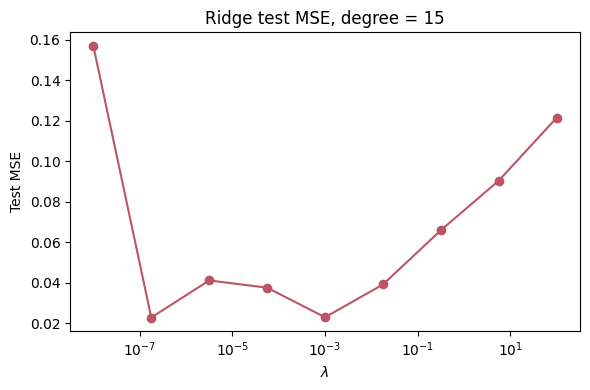

In [52]:
plt.figure(figsize=(6, 4))

plt.semilogx( lambdas,mse_ridge, "o-", color=RED)

plt.xlabel(r"$\lambda$")
plt.ylabel("Test MSE")
plt.title(f"Ridge test MSE, degree = {degree}")

plt.tight_layout()
plt.show()

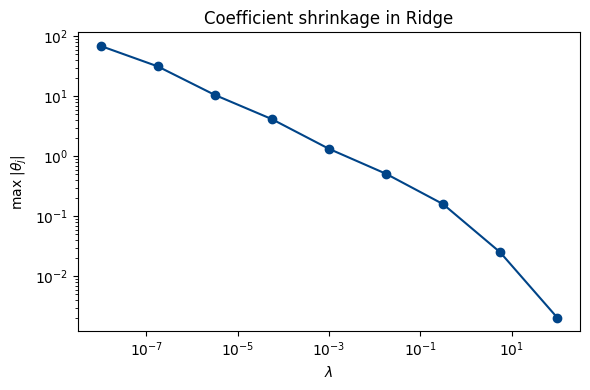

In [53]:
max_theta_ridge= np.zeros(len(lambdas))

for i, theta in enumerate(theta_ridge_all):
    max_theta_ridge[i]= np.max(np.abs(theta_ridge_all[i]))

plt.figure(figsize=(6, 4))
plt.loglog(lambdas, max_theta_ridge, "o-",color=BLUE
)

plt.xlabel(r"$\lambda$")
plt.ylabel(r"max $|\theta_j|$")
plt.title("Coefficient shrinkage in Ridge")

plt.tight_layout()
plt.show()


In [54]:
# comparing OLS and Ridge

y_train_pred_ols , y_test_pred_ols, theta_ols= fit_predict(x_train, x_test, y_train, degree, lam=0.0)

y_train_pred_ridge, y_test_pred_ridge, theta_ridge= fit_predict(x_train, x_test, y_train, degree, lam= 0.01)

print(f"OLS: MSE = {MSE(y_test, y_test_pred_ols)}, R2 = {R2(y_test, y_test_pred_ols)}")
print(f"Ridge: MSE = {MSE(y_test, y_test_pred_ridge)}, R2 = {R2(y_test, y_test_pred_ridge)}")

print("OLS max |theta|   :", np.max(np.abs(theta_ols)))
print("Ridge max |theta| :", np.max(np.abs(theta_ridge)))

OLS: MSE = 0.18336464980881823, R2 = -0.47775866834483516
Ridge: MSE = 0.0338497467689314, R2 = 0.7272006531181434
OLS max |theta|   : 469.21920913085194
Ridge max |theta| : 0.6046401694155344


## b.3 MSE against degree, for several $\lambda$

In [55]:
lambdas_sweep = [0.0, 1e-6, 1e-4, 1e-2, 1.0]
mse_by_lambda = {}


for lam in lambdas_sweep:

    mse_deg= np.zeros(len(degrees))
    for i , deg in enumerate(degrees):
        y_train_pred, y_test_pred, theta= fit_predict(x_train, x_test, y_train, deg, lam=lam)
        mse_deg[i]= MSE(y_test, y_test_pred)

    mse_by_lambda[lam]= mse_deg



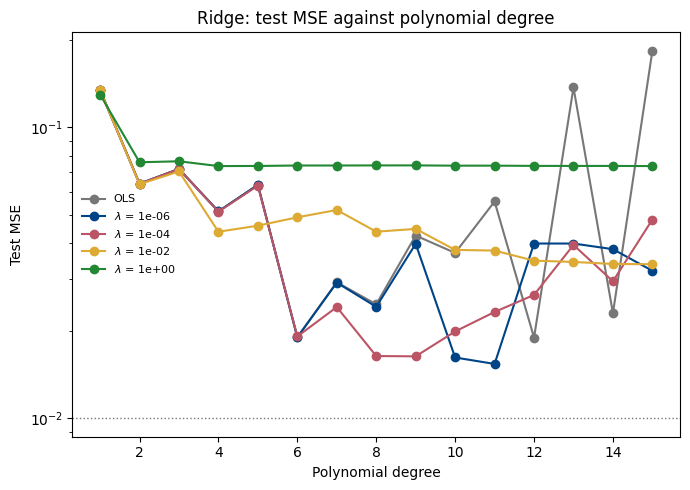

In [56]:
colors_b3 = [GREY, BLUE, RED, YELLOW, GREEN]
  
plt.figure(figsize=(7, 5))

for i, lam in enumerate(lambdas_sweep):
 
    label = "OLS" if lam == 0.0 else fr"$\lambda$ = {lam:.0e}"

    plt.semilogy(degrees, mse_by_lambda[lam], "o-", color=colors_b3[i], label=label)
  

plt.axhline(0.1**2, color=GREY, linestyle=":", linewidth=1)
  
plt.xlabel("Polynomial degree")
plt.ylabel("Test MSE")
plt.title("Ridge: test MSE against polynomial degree")
plt.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig("../results/b3_mse_degree.pdf", bbox_inches="tight")
plt.show()

## b.4 Coefficient paths

Plot $\theta_j$ against $\lambda$ (log axis). Watch every coefficient shrink smoothly
toward zero — but **never reach it exactly**. That is the difference from Lasso in
part g).

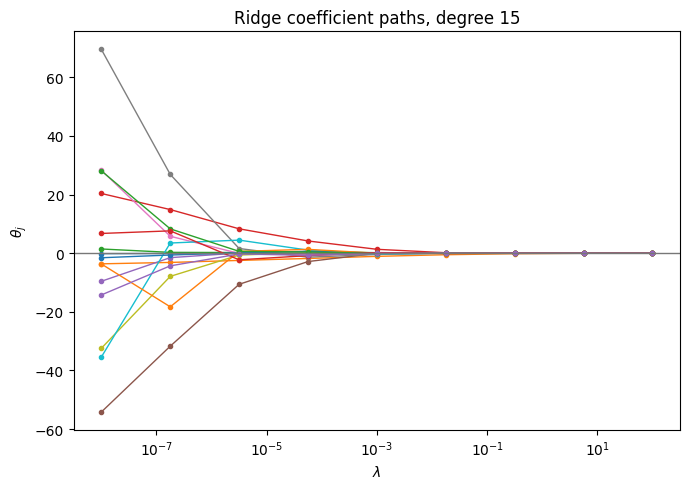

In [57]:
theta_paths = np.array(theta_ridge_all)

plt.figure(figsize=(7, 5))

for j in range(theta_paths.shape[1]):
      plt.semilogx(lambdas, theta_paths[:, j], "o-", linewidth=1, markersize=3)
 

plt.axhline(0, color=GREY, linewidth=1)
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\theta_j$")
plt.title("Ridge coefficient paths, degree 15")
 
plt.tight_layout()
plt.savefig("../results/b4_coef_paths.pdf", bbox_inches="tight")
plt.show()
  


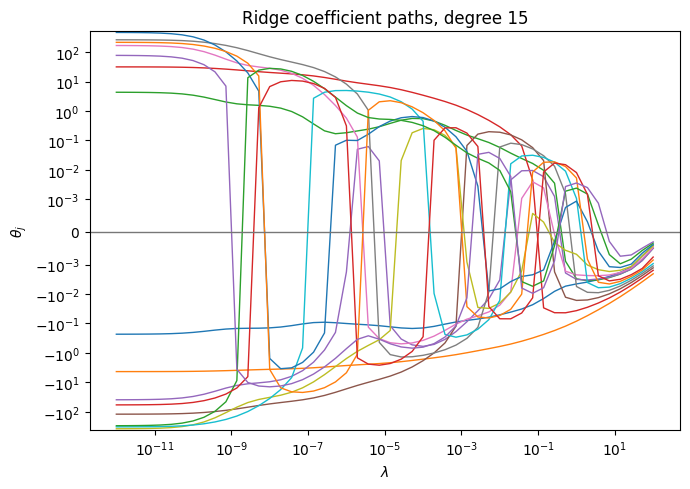

smallest |theta| at lam = 100: 0.0003029802222823352
any coefficient exactly zero: False


In [58]:
lambdas_paths = np.logspace(-12, 2, 50)

theta_paths = np.array([fit_predict(x_train, x_test, y_train, 15, lam=lam)[2]
                          for lam in lambdas_paths])

plt.figure(figsize=(7, 5))

for j in range(theta_paths.shape[1]):
      plt.semilogx(lambdas_paths, theta_paths[:, j], "-", linewidth=1)

plt.axhline(0, color=GREY, linewidth=1)
plt.yscale("symlog", linthresh=1e-3)

plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\theta_j$")
plt.title("Ridge coefficient paths, degree 15")

plt.tight_layout()
plt.savefig("../results/b4_coef_paths.pdf", bbox_inches="tight")
plt.show()

print("smallest |theta| at lam = 100:", np.min(np.abs(theta_paths[-1])))
print("any coefficient exactly zero:", np.any(theta_paths == 0))



## b.5 The SVD picture

With $X = U\Sigma V^T$, the two estimators differ only by a factor on each singular
direction:

| | coefficient on direction $j$ |
|---|---|
| OLS | $\dfrac{1}{\sigma_j}(u_j^Ty)$ |
| Ridge | $\dfrac{\sigma_j}{\sigma_j^2+\lambda}(u_j^Ty)$ |

so Ridge applies the shrinkage factor $\sigma_j^2/(\sigma_j^2+\lambda)$: directions with
large $\sigma_j$ pass through untouched, directions with small $\sigma_j$ are crushed.

Compute the singular values of your degree-15 design matrix, plot the shrinkage
factor for a few $\lambda$, and connect it to the coefficient explosion in a.4.

---
# Part c) Bias-variance tradeoff and the bootstrap

## Goal: Show the U-shaped test-MSE curve is just variance increasing and bias falling as the model gets complex by implementing bootstrap. Only using the OLS here.

## c.1 Train/test MSE vs complexity

Before doing the analysis, we must reproduce the Fig 2.11 of Hastie, Tibshirani and Friedman. By only doing a test/train - split and plotting the resulting MSE against the polynomial degree. Increase the max degree and use more than one value of n --> so that we get a clear U-shape.

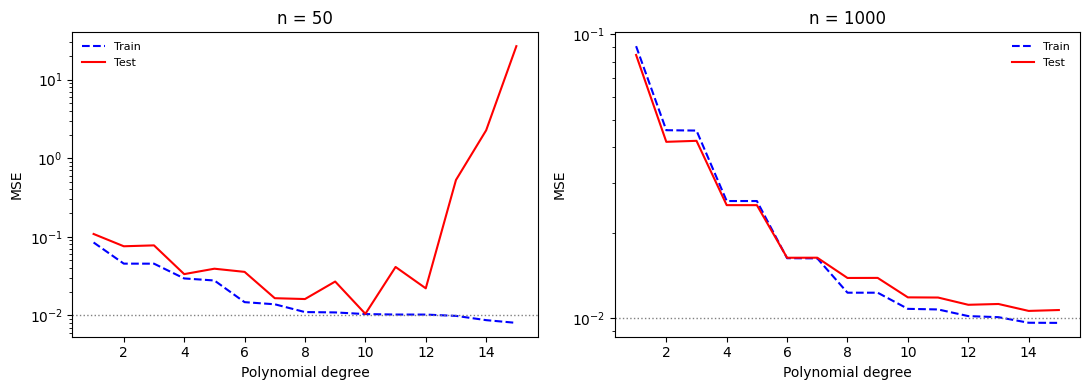

In [71]:
degrees_c1 = np.arange(1,21)


mse_train_by_n = {}
mse_test_by_n = {}
sigma = 0.1
#same structure as in a5
for n in n_values:
    x_n, y_n = make_data(n=n, sigma = 0.1, seed=2026)
    x_train_n , x_test_n, y_train_n, y_test_n = train_test_split(x_n,y_n, test_size = 0.2, random_state = 2026)

    mse_train = np.zeros(len(degrees))
    mse_test = np.zeros(len(degrees))

    for i, degree in enumerate(degrees):
        y_train_pred, y_test_pred, theta = fit_predict(x_train_n, x_test_n, y_train_n, degree)
        mse_train[i] = MSE(y_train_n, y_train_pred)
        mse_test[i] = MSE(y_test_n, y_test_pred)

    mse_train_by_n[n] = mse_train
    mse_test_by_n[n] = mse_test

    
#plotting
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

n_small = 50
n_large = 1000

axes[0].semilogy(degrees, mse_train_by_n[n_small], "--", color= "BLUE", label= "Train")
axes[0].semilogy(degrees,mse_test_by_n[n_small], "-", color = "RED", label = "Test")
axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("MSE")
axes[0].axhline(sigma**2, color="gray", linestyle=":", linewidth=1)
axes[0].set_title(f"n = {n_small}")
axes[0].legend(frameon=False, fontsize=8)

axes[1].semilogy(degrees,mse_train_by_n[n_large], "--", color = "BLUE", label = "Train")
axes[1].semilogy(degrees,mse_test_by_n[n_large], "-", color = "RED", label = "Test")
axes[1].set_xlabel("Polynomial degree")
axes[1].set_ylabel("MSE")
axes[1].axhline(sigma**2, color="gray", linestyle=":", linewidth=1)
axes[1].set_title(f"n = {n_large}")
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()




## c.2 Bootstrap: bias-variance vs degree

For each degree, resample the training set by using bootstrap. Refit to every resample and estimate: error, bias and variance.

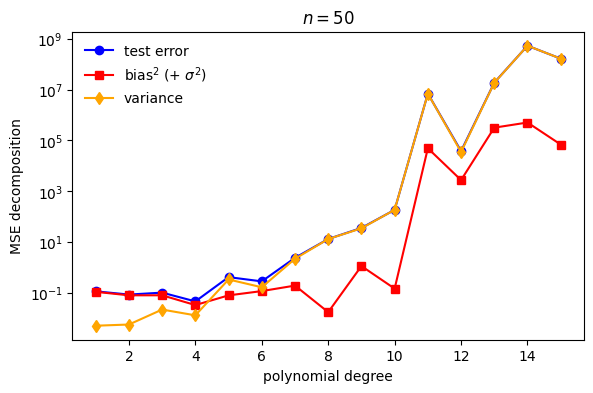

In [64]:
#c2

from sklearn.utils import resample



def bias_variance_sweep(x,y,degrees, n_bootstrap = 100, seed = 2026):
    x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = seed)
    y_test_col = y_test.reshape(-1,1) #make it a coloumn vector

    error = np.zeros(len(degrees))
    bias = np.zeros(len(degrees))
    variance = np.zeros(len(degrees))

    for idx, degree in enumerate(degrees):
        y_pred = np.empty((y_test.shape[0], n_bootstrap)) 

        for i in range(n_bootstrap):
            x_, y_ = resample(x_train,y_train)

            #Using fit_predict from your code:

            y_train_pred, y_test_pred, theta = fit_predict(x_,x_test, y_,degree)
            y_pred[:,i] = y_test_pred

        error[idx] = np.mean(np.mean((y_test_col - y_pred)**2, axis = 1, keepdims = True))
        bias[idx] = np.mean((y_test_col - np.mean(y_pred, axis = 1, keepdims = True ))**2)
        variance[idx] = np.mean(np.var(y_pred, axis = 1, keepdims = True))

    return error, bias, variance


x_n50, y_n50 = make_data(n=50, sigma=0.1, seed=2026)
n_c2 = 50
error, bias, variance = bias_variance_sweep(x_n50,y_n50, degrees ,n_bootstrap = 100, seed = 2026)


fig, axes = plt.subplots(figsize=(6.6, 4.0))
axes.plot(degrees, error, "o-", color="blue", label="test error")
axes.plot(degrees, bias, "s-", color="red", label=r"bias$^2$ (+ $\sigma^2$)")
axes.plot(degrees, variance, "d-", color="orange", label="variance")
axes.set_yscale("log")
axes.set_xlabel("polynomial degree")
axes.set_ylabel("MSE decomposition")
axes.set_title(f"$n = {n_c2}$")
axes.legend(frameon=False)
plt.show()





## c.3 Dependence on the number of data points (n)

Reusing the c2 analysis for different values of n.

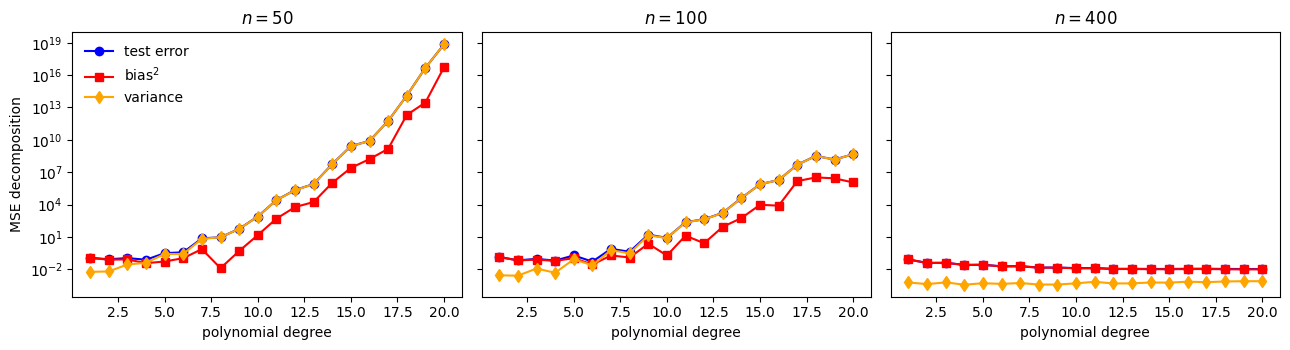

In [ ]:
#c3

#Using bias_variance_sweep from c2

#Setting up our data:

#degrees_c2 = np.arange(1,21) #same degrees as c1
n_values_c2 = [50,100,400]

# Using the function to show how it changes with different n sizes

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, n in zip(axes, n_values_c2):
    x_n , y_n = make_data(n=n, sigma = 0.1, seed = 2026)
    err, b2, var = bias_variance_sweep(x_n,y_n, degrees, n_bootstrap = 100)


    ax.plot(degrees, err, "o-", color="blue", label="test error")
    ax.plot(degrees, b2, "s-", color="red", label=r"bias$^2$")
    ax.plot(degrees, var, "d-", color="orange", label="variance")
    ax.set_yscale("log")
    ax.set_title(f"$n = {n}$")
    ax.set_xlabel("polynomial degree")
axes[0].set_ylabel("MSE decomposition")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()


---
# Part d) Cross-validation

# Goal

Use K-fold cross-validation of sklearn and evaluate against MSE test results for OLS from a) and c), as a function of polynomoial degree, and for for Ridge as a function of both polynomial degree and lambda. Use k =5, and k = 10.

Compare the results from cross-val with the one we got from bootstrap in c)


## d.1 
Setup K-fold and cross val

In [62]:
from sklearn.model_selection import KFold, cross_val_score

k = [5,10]


---
# Part e) Gradient descent, analytical and automatic gradients

---
# Part f) Momentum, AdaGrad, RMSprop and Adam

---
# Part g) Lasso regression

---
# Part h) Stochastic gradient descent

---
# Part i) Final comparison: OLS, Ridge and Lasso with cross-validation